Dataset loaded successfully.

Date-related features engineered successfully.

Found 49 rows with zero or negative prices. These rows will be removed.

Price column description after handling invalid prices:
count    4.551000e+03
mean     5.579059e+05
std      5.639299e+05
min      7.800000e+03
25%      3.262643e+05
50%      4.650000e+05
75%      6.575000e+05
max      2.659000e+07
Name: price, dtype: float64


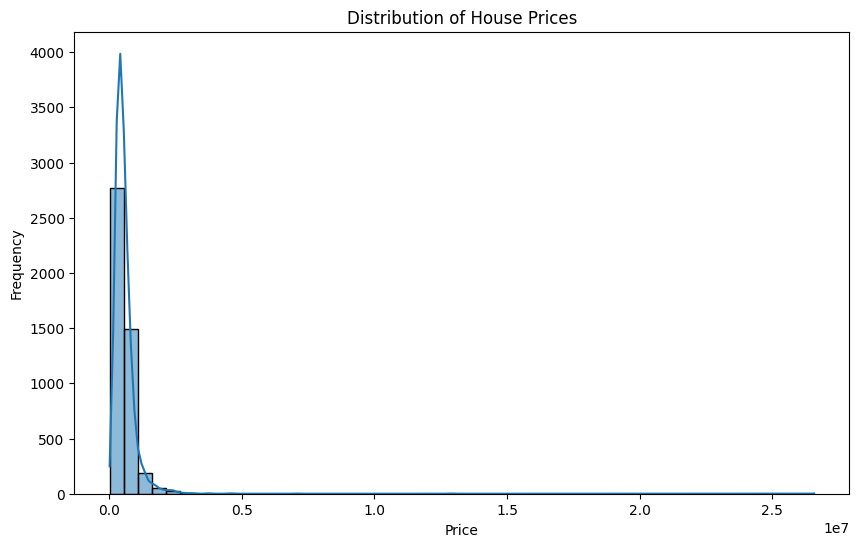


First 5 rows of the dataset after feature engineering:
       price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0   313000.0       3.0       1.50         1340      7912     1.5           0   
1  2384000.0       5.0       2.50         3650      9050     2.0           0   
2   342000.0       3.0       2.00         1930     11947     1.0           0   
3   420000.0       3.0       2.25         2000      8030     1.0           0   
4   550000.0       4.0       2.50         1940     10500     1.0           0   

   view  condition  sqft_above  sqft_basement                    street  \
0     0          3        1340              0      18810 Densmore Ave N   
1     4          5        3370            280           709 W Blaine St   
2     0          4        1930              0  26206-26214 143rd Ave SE   
3     0          4        1000           1000           857 170th Pl NE   
4     0          4        1140            800         9105 170th Ave NE   

        city

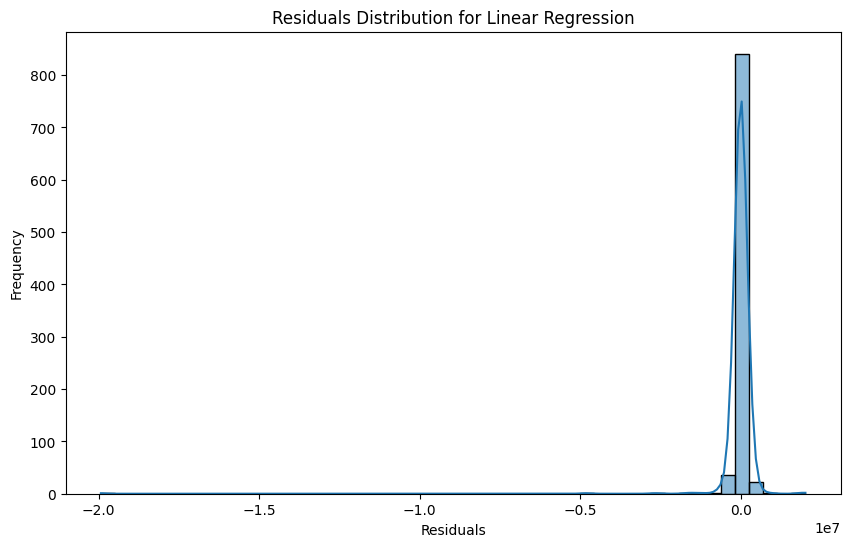

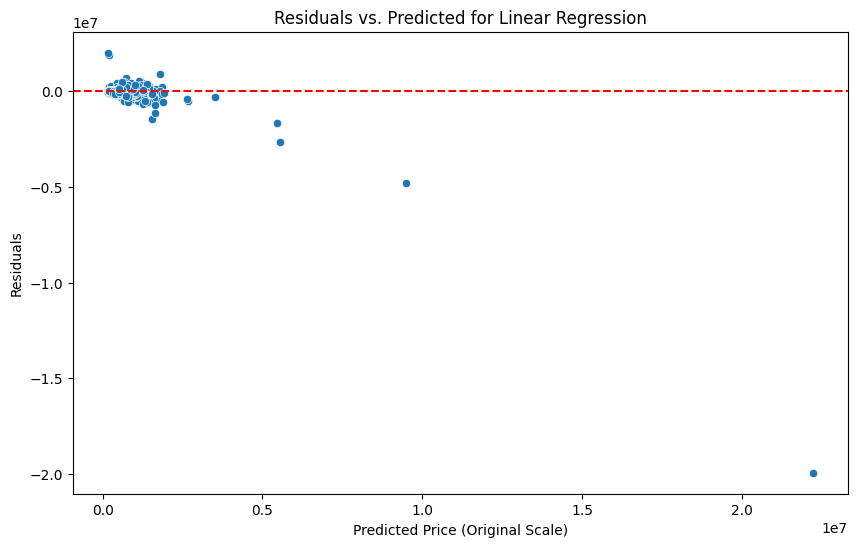


Training Random Forest...
Random Forest - RMSE: 222032.68, MAE: 111751.14, R2: 0.67


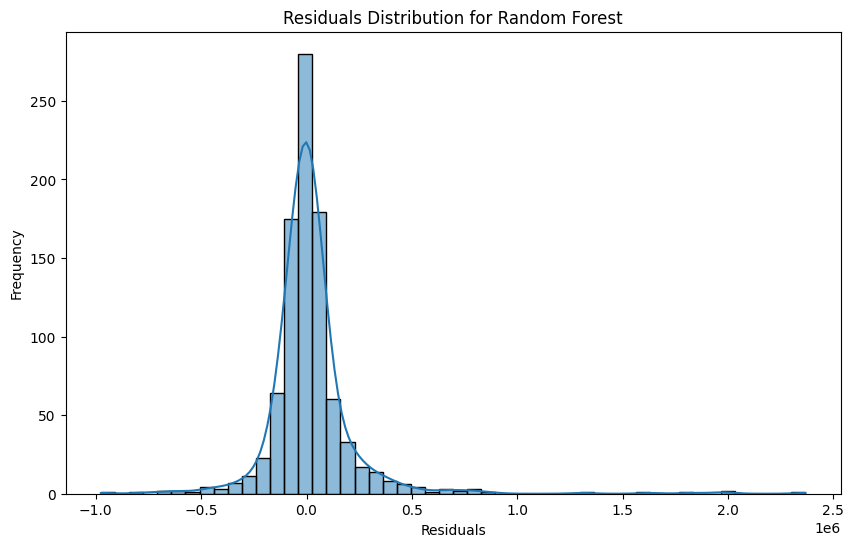

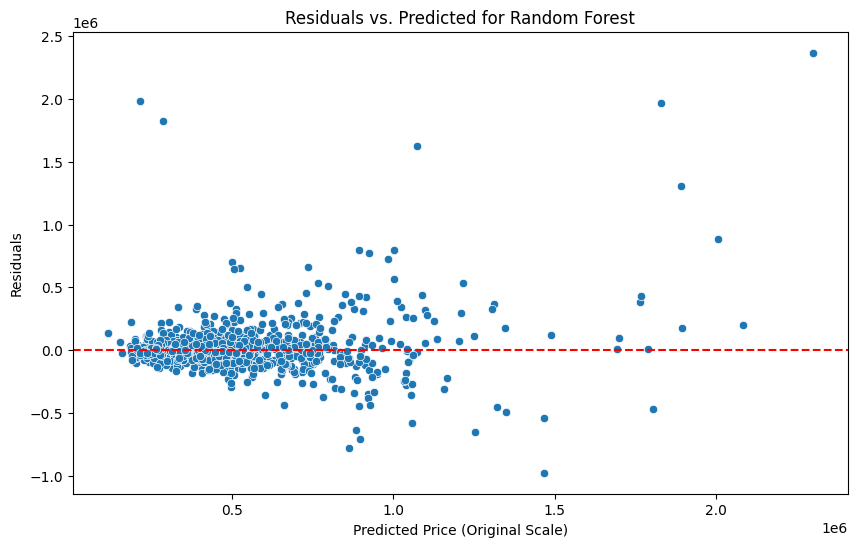


Training Gradient Boosting...
Gradient Boosting - RMSE: 219204.42, MAE: 113062.49, R2: 0.68


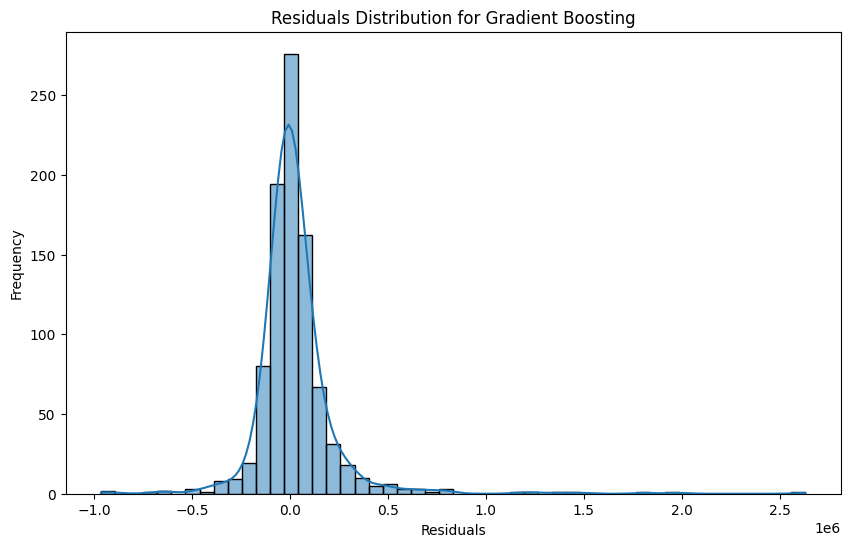

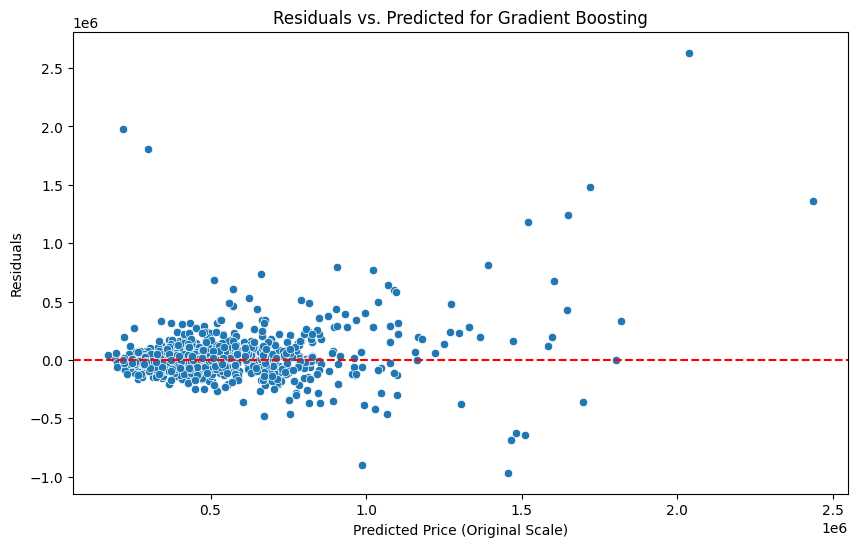


Model Comparison:
Linear Regression: RMSE=708128.95, MAE=121737.44, R2=-2.37
Random Forest: RMSE=222032.68, MAE=111751.14, R2=0.67
Gradient Boosting: RMSE=219204.42, MAE=113062.49, R2=0.68


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the dataset
try:
    df = pd.read_csv('/content/data[1].csv')
    print("Dataset loaded successfully.")

    # Convert 'date' column to datetime objects
    df['date'] = pd.to_datetime(df['date'])

    # Extract year and month from 'date'
    df['sale_year'] = df['date'].dt.year
    df['sale_month'] = df['date'].dt.month
    df['sale_day'] = df['date'].dt.day

    # Calculate age of the house at the time of sale
    df['house_age'] = df['sale_year'] - df['yr_built']
    df['years_since_renovation'] = df['sale_year'] - df['yr_renovated']

    # For houses that were never renovated (yr_renovated is 0), set years_since_renovation to house_age
    df.loc[df['yr_renovated'] == 0, 'years_since_renovation'] = df['house_age']

    # Drop original 'date', 'yr_built', and 'yr_renovated' columns as new features have been created
    df = df.drop(['date', 'yr_built', 'yr_renovated'], axis=1)

    print("\nDate-related features engineered successfully.")

    # Check for zero or negative prices, which are invalid
    invalid_prices = df[(df['price'] <= 0)]
    if not invalid_prices.empty:
        print(f"\nFound {len(invalid_prices)} rows with zero or negative prices. These rows will be removed.")
        df = df[df['price'] > 0]

    # Display basic statistics for 'price'
    print("\nPrice column description after handling invalid prices:")
    print(df['price'].describe())

    # Visualize price distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['price'], bins=50, kde=True)
    plt.title('Distribution of House Prices')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()

    print("\nFirst 5 rows of the dataset after feature engineering:")
    print(df.head())
    print("\nDataset Info after feature engineering:")
    df.info()
    print("\nMissing values per column after feature engineering:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

    # Log transform the 'price' target variable to reduce skewness
    df['price'] = np.log1p(df['price'])
    print("\n'price' column log-transformed successfully.")

    # Drop 'country' if it has only one unique value (or is not useful)
    if 'country' in df.columns and df['country'].nunique() == 1:
        df = df.drop('country', axis=1)
        print("Dropped 'country' column as it has only one unique value.")

    # Drop 'street' column as it's often too granular for direct use and can be high cardinality
    if 'street' in df.columns:
        df = df.drop('street', axis=1)
        print("Dropped 'street' column.")

    # Identify categorical and numerical features for preprocessing
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()
    numerical_features = df.select_dtypes(include=np.number).columns.tolist()
    # Remove 'price' from numerical_features as it's the target
    if 'price' in numerical_features:
        numerical_features.remove('price')

    print(f"\nCategorical features identified: {categorical_features}")
    print(f"Numerical features identified (excluding target): {numerical_features}")

    # Create a column transformer for preprocessing
    # One-hot encode categorical features and scale numerical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ],
        remainder='passthrough'
    )

    # Apply preprocessing
    # We need to separate features (X) and target (y) first
    X = df.drop('price', axis=1)
    y = df['price']

    # Fit and transform the features, ensuring dense output
    X_processed = preprocessor.fit_transform(X).toarray() # Convert to dense array

    # Get feature names after one-hot encoding
    # The order of features in all_feature_names should match the order from preprocessor.fit_transform(X)
    # ColumnTransformer first outputs numerical features, then categorical
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = numerical_features + ohe_feature_names.tolist()

    # Convert processed features back to DataFrame
    X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)

    print("\nFeatures preprocessed successfully (one-hot encoded and scaled).")
    print("\nFirst 5 rows of processed features:")
    print(X_processed_df.head())
    print("\nShape of processed features:", X_processed_df.shape)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42)
    print(f"\nData split into training and testing sets. Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42)
    }

    results = {}
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Inverse transform the predictions to original price scale
        y_pred_original = np.expm1(y_pred)
        y_test_original = np.expm1(y_test)

        rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        mae = mean_absolute_error(y_test_original, y_pred_original)
        r2 = r2_score(y_test_original, y_pred_original)

        results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
        print(f"{name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

        # Residual Analysis
        residuals = y_test_original - y_pred_original
        plt.figure(figsize=(10, 6))
        sns.histplot(residuals, bins=50, kde=True)
        plt.title(f'Residuals Distribution for {name}')
        plt.xlabel('Residuals')
        plt.ylabel('Frequency')
        plt.show()

        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=y_pred_original, y=residuals)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.title(f'Residuals vs. Predicted for {name}')
        plt.xlabel('Predicted Price (Original Scale)')
        plt.ylabel('Residuals')
        plt.show()

    print("\nModel Comparison:")
    for name, metrics in results.items():
        print(f"{name}: RMSE={metrics['RMSE']:.2f}, MAE={metrics['MAE']:.2f}, R2={metrics['R2']:.2f}")


except FileNotFoundError:
    print("Error: The file '/content/data[1].csv' was not found. Please ensure it's uploaded correctly.")
except Exception as e:
    print(f"An error occurred while loading or processing the dataset: {e}")

### Model Summary and Best Model Selection

Based on the evaluation metrics, **Gradient Boosting** performed slightly better than Random Forest, and significantly better than Linear Regression. We will proceed with the Gradient Boosting model for demonstration.



In [7]:
import joblib

# Assuming 'preprocessor' and 'models' (containing the trained Gradient Boosting model) are available from previous steps

# Select the best performing model (Gradient Boosting in this case)
best_model = models['Gradient Boosting']

# Save the preprocessor and the best model
joblib.dump(preprocessor, 'house_price_preprocessor.pkl')
joblib.dump(best_model, 'house_price_gradient_boosting_model.pkl')

print("Preprocessor and Best Model (Gradient Boosting) saved successfully.")

# --- Demonstration of using the saved model for prediction ---

# Create a sample new data point (replace with actual new data)
# This dictionary should mimic the structure of a single row in your original DataFrame before preprocessing
sample_new_data = pd.DataFrame([
    {
        'bedrooms': 3.0,
        'bathrooms': 2.0,
        'sqft_living': 1800,
        'sqft_lot': 7000,
        'floors': 1.0,
        'waterfront': 0,
        'view': 0,
        'condition': 3,
        'sqft_above': 1800,
        'sqft_basement': 0,
        'street': '123 Main St',
        'city': 'Shoreline',
        'statezip': 'WA 98133',
        'country': 'USA',
        'sale_year': 2014,
        'sale_month': 5,
        'sale_day': 2,
        'house_age': 50,
        'years_since_renovation': 10
    }
])

print("\nSample new data for prediction:")
print(sample_new_data)

# Load the saved preprocessor and model
loaded_preprocessor = joblib.load('house_price_preprocessor.pkl')
loaded_model = joblib.load('house_price_gradient_boosting_model.pkl')

# Preprocess the new data using the loaded preprocessor
# Drop 'country' and 'street' if they were dropped during training
if 'country' in sample_new_data.columns and sample_new_data['country'].nunique() == 1:
    sample_new_data = sample_new_data.drop('country', axis=1)
if 'street' in sample_new_data.columns:
    sample_new_data = sample_new_data.drop('street', axis=1)

# Ensure the columns in sample_new_data match the X used for preprocessor fitting
# This step is crucial if the order or presence of columns can vary
# For simplicity, assuming sample_new_data already has necessary features or more are handled by one-hot encoder

# Identify categorical and numerical features based on the training process
# These lists should ideally be saved with the preprocessor or derived consistently
categorical_features_sample = sample_new_data.select_dtypes(include=['object']).columns.tolist()
numerical_features_sample = sample_new_data.select_dtypes(include=np.number).columns.tolist()

# It's important that the order of columns and features passed to the preprocessor is consistent
# The preprocessor expects the same numerical and categorical columns it was trained on.
# If `sample_new_data` does not have all columns that were in `X` when preprocessor was fitted,
# it might raise errors or produce incorrect results. For a robust solution, ensure `sample_new_data`
# has all columns of original `X` and then drop `street` and `country` or align them before passing to preprocessor.

# To be safe, re-align columns for prediction if needed
# For demonstration, we'll assume the sample data has the correct structure for preprocessing

X_new_processed = loaded_preprocessor.transform(sample_new_data).toarray()

# Get feature names after one-hot encoding for the new data if needed for debugging or inspection
ohe_feature_names_loaded = loaded_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names_loaded = numerical_features + ohe_feature_names_loaded.tolist()

X_new_processed_df = pd.DataFrame(X_new_processed, columns=all_feature_names_loaded, index=sample_new_data.index)

print("\nProcessed new data for prediction (first 5 features):")
print(X_new_processed_df.head())

# Make prediction
predicted_log_price = loaded_model.predict(X_new_processed_df)

# Inverse transform the log-predicted price to the original scale
predicted_original_price = np.expm1(predicted_log_price)

print(f"\nPredicted house price for the sample data: ${predicted_original_price[0]:,.2f}")


Preprocessor and Best Model (Gradient Boosting) saved successfully.

Sample new data for prediction:
   bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0       3.0        2.0         1800      7000     1.0           0     0   

   condition  sqft_above  sqft_basement       street       city  statezip  \
0          3        1800              0  123 Main St  Shoreline  WA 98133   

  country  sale_year  sale_month  sale_day  house_age  years_since_renovation  
0     USA       2014           5         2         50                      10  

Processed new data for prediction (first 5 features):
   bedrooms  bathrooms  sqft_living  sqft_lot    floors  waterfront      view  \
0 -0.436308  -0.199701    -0.347726 -0.217888 -0.951201    -0.08146 -0.306647   

   condition  sqft_above  sqft_basement  ...  statezip_WA 98155  \
0  -0.665622    -0.02601      -0.671413  ...                0.0   

   statezip_WA 98166  statezip_WA 98168  statezip_WA 98177  statezip_WA 98178  \